In [1]:
import os
print(os.environ["LD_LIBRARY_PATH"])

/users/eleves-b/2024/yiming.chen/miniconda3/envs/drag/lib


In [2]:
from diffusers import DDIMScheduler, AutoencoderKL
from pytorch_lightning import seed_everything
from drag_pipeline import DragPipeline
from utils.drag_utils import drag_diffusion_update
from utils.attn_utils import register_attention_editor_diffusers, MutualSelfAttentionControl
from types import SimpleNamespace
from copy import deepcopy
from einops import rearrange
import numpy as np
import torch
import torch.nn.functional as F

def preprocess_image(image, device):
    image = torch.from_numpy(image).float() / 127.5 - 1 # [-1, 1]
    image = rearrange(image, "h w c -> 1 c h w")
    image = image.to(device)
    return image

def convert_points(points, full_h, full_w, sup_res_h, sup_res_w):
    handle_points, target_points = [], []
    for idx, point in enumerate(points):
        cur_point = torch.tensor([point[1]/full_h*sup_res_h, point[0]/full_w*sup_res_w])
        cur_point = torch.round(cur_point)
        if idx % 2 == 0:
            handle_points.append(cur_point)
        else:
            target_points.append(cur_point)
    return handle_points, target_points

def run_drag(source_image,
             # image_with_clicks,
             mask,
             prompt,
             points,
             inv_strength,
             lam,
             latent_lr,
             unet_feature_idx,
             n_pix_step,
             model_path,
             vae_path,
             lora_path,
             start_step,
             start_layer,
             # save_dir="./results"
    ):
    # initialize model
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012,
                          beta_schedule="scaled_linear", clip_sample=False,
                          set_alpha_to_one=False, steps_offset=1)
    model = DragPipeline.from_pretrained(model_path, scheduler=scheduler).to(device)
    # call this function to override unet forward function,
    # so that intermediate features are returned after forward
    model.modify_unet_forward()

    # set vae
    if vae_path != "default":
        model.vae = AutoencoderKL.from_pretrained(
            vae_path
        ).to(model.vae.device, model.vae.dtype)

    # initialize parameters
    seed = 42 # random seed used by a lot of people for unknown reason
    seed_everything(seed)

    args = SimpleNamespace()
    args.prompt = prompt
    args.points = points
    args.n_inference_step = 50
    args.n_actual_inference_step = round(inv_strength * args.n_inference_step)
    args.guidance_scale = 1.0

    args.unet_feature_idx = [unet_feature_idx]

    args.r_m = 1
    args.r_p = 3
    args.lam = lam

    args.lr = latent_lr
    args.n_pix_step = n_pix_step

    full_h, full_w = source_image.shape[:2]
    args.sup_res_h = int(0.5*full_h)
    args.sup_res_w = int(0.5*full_w)

    print(args)

    source_image = preprocess_image(source_image, device)
    # image_with_clicks = preprocess_image(image_with_clicks, device)

    # set lora
    if lora_path == "":
        print("applying default parameters")
        model.unet.set_default_attn_processor()
    else:
        print("applying lora: " + lora_path)
        model.unet.load_attn_procs(lora_path)

    # invert the source image
    # the latent code resolution is too small, only 64*64
    invert_code = model.invert(source_image,
                               prompt,
                               guidance_scale=args.guidance_scale,
                               num_inference_steps=args.n_inference_step,
                               num_actual_inference_steps=args.n_actual_inference_step)

    mask = torch.from_numpy(mask).float() / 255.
    mask[mask > 0.0] = 1.0
    mask = rearrange(mask, "h w -> 1 1 h w").cuda()
    mask = F.interpolate(mask, (args.sup_res_h, args.sup_res_w), mode="nearest")

    handle_points, target_points = convert_points(points, full_h, full_w,
                                                 args.sup_res_h, args.sup_res_w)

    init_code = invert_code
    init_code_orig = deepcopy(init_code)
    model.scheduler.set_timesteps(args.n_inference_step)
    t = model.scheduler.timesteps[args.n_inference_step - args.n_actual_inference_step]

    # feature shape: [1280,16,16], [1280,32,32], [640,64,64], [320,64,64]
    # update according to the given supervision
    updated_init_code = drag_diffusion_update(model, init_code,
        None, t, handle_points, target_points, mask, args)

    # hijack the attention module
    # inject the reference branch to guide the generation
    editor = MutualSelfAttentionControl(start_step=start_step,
                                        start_layer=start_layer,
                                        total_steps=args.n_inference_step,
                                        guidance_scale=args.guidance_scale)
    if lora_path == "":
        register_attention_editor_diffusers(model, editor, attn_processor='attn_proc')
    else:
        register_attention_editor_diffusers(model, editor, attn_processor='lora_attn_proc')

    # inference the synthesized image
    gen_image = model(
        prompt=args.prompt,
        batch_size=2,
        latents=torch.cat([init_code_orig, updated_init_code], dim=0),
        guidance_scale=args.guidance_scale,
        num_inference_steps=args.n_inference_step,
        num_actual_inference_steps=args.n_actual_inference_step
        )[1].unsqueeze(dim=0)

    # resize gen_image into the size of source_image
    # we do this because shape of gen_image will be rounded to multipliers of 8
    gen_image = F.interpolate(gen_image, (full_h, full_w), mode='bilinear')

    # save the original image, user editing instructions, synthesized image
    # save_result = torch.cat([
    #     source_image * 0.5 + 0.5,
    #     torch.ones((1,3,full_h,25)).cuda(),
    #     image_with_clicks * 0.5 + 0.5,
    #     torch.ones((1,3,full_h,25)).cuda(),
    #     gen_image[0:1]
    # ], dim=-1)

    # if not os.path.isdir(save_dir):
    #     os.mkdir(save_dir)
    # save_prefix = datetime.datetime.now().strftime("%Y-%m-%d-%H%M-%S")
    # save_image(save_result, os.path.join(save_dir, save_prefix + '.png'))

    out_image = gen_image.cpu().permute(0, 2, 3, 1).numpy()[0]
    out_image = (out_image * 255).astype(np.uint8)
    return out_image

In [ ]:
# You need to install ipywidgets and ipycanvas to use the following code
# %pip install ipywidgets ipycanvas

from utils.widget_editor import MaskPainter
from utils.widget_editor import PointArrowEditor
from PIL import Image

img = Image.open("assets/ferriswheel.png").convert("RGB")
img_np = np.array(img)

In [5]:
painter = MaskPainter(img_np, brush_radius=40)
painter.show()

Canvas(height=400, width=600)

In [6]:
editor = PointArrowEditor(img_np)
editor.show()

Canvas(height=400, width=600)

In [7]:
mask = painter.get_mask()
points = editor.get_points()
prompt = "a photo of a ferris whell at sunset"

In [8]:
from dataclasses import dataclass
from utils.lora_utils import train_lora
import tqdm

@dataclass
class LoraConfig:
    model_path = "runwayml/stable-diffusion-v1-5"
    vae_path = "default"
    lora_steps: int = 80
    inv_strength: float = 0.7
    lora_lr: float = 1e-4
    lora_rank: int = 16
    lora_batch_size: int = 4
    lora_save_dir: str = "lora_tmp/ferris_wheel/"    

lora_config = LoraConfig()

assert lora_config.model_path in [
     "runwayml/stable-diffusion-v1-5",
     "gsdf/Counterfeit-V2.5",
     "stablediffusionapi/anything-v5",
     "SG161222/Realistic_Vision_V2.0",
]
assert lora_config.vae_path in ["default", "stabilityai/sd-vae-ft-mse"]

train_lora(
    img_np,
    prompt,
    lora_config.model_path,
    lora_config.vae_path,
    lora_save_dir=lora_config.lora_save_dir,
    lora_steps=lora_config.lora_steps,
    lora_lr=lora_config.lora_lr,
    lora_batch_size=lora_config.lora_batch_size,
    lora_rank=lora_config.lora_rank
)

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
training LoRA: 100%|██████████| 80/80 [00:42<00:00,  1.90it/s]


In [9]:
class DragConfig:
    inv_strength: float = 0.7
    lam: float = 0.1
    latent_lr: float = 0.01
    unet_feature_idx: int = 3
    n_pix_step: int = 80
    start_step: int = 0
    start_layer: int = 10

drag_config = DragConfig()

out_image = run_drag(
    img_np,
    mask,
    prompt,
    points,
    # drag config
    inv_strength=drag_config.inv_strength,
    lam=drag_config.lam,
    latent_lr=drag_config.latent_lr,
    unet_feature_idx=drag_config.unet_feature_idx,
    n_pix_step=drag_config.n_pix_step,
    # lora config
    model_path=lora_config.model_path,
    vae_path=lora_config.vae_path,
    lora_path=lora_config.lora_save_dir,
    start_step=drag_config.start_step,
    start_layer=drag_config.start_layer,
    # save_dir="./results"
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
Global seed set to 42


namespace(guidance_scale=1.0, lam=0.1, lr=0.01, n_actual_inference_step=35, n_inference_step=50, n_pix_step=80, points=[(257.4285697937012, 175.42820927213978), (182.42856979370117, 207.42820683073373), (352.4285697937012, 214.42820629667617), (269.4285697937012, 283.4282010323943)], prompt='a photo of a ferris whell at sunset', r_m=1, r_p=3, sup_res_h=200, sup_res_w=300, unet_feature_idx=[3])
applying lora: lora_tmp/ferris_wheel/
latents shape:  torch.Size([1, 4, 50, 75])
Valid timesteps:  tensor([  1,  21,  41,  61,  81, 101, 121, 141, 161, 181, 201, 221, 241, 261,
        281, 301, 321, 341, 361, 381, 401, 421, 441, 461, 481, 501, 521, 541,
        561, 581, 601, 621, 641, 661, 681, 701, 721, 741, 761, 781, 801, 821,
        841, 861, 881, 901, 921, 941, 961, 981])


DDIM Inversion: 100%|██████████| 50/50 [00:02<00:00, 17.68it/s]


step_idx:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
layer_idx:  [10, 11, 12, 13, 14, 15]
latents shape:  torch.Size([2, 4, 50, 75])


DDIM Sampler: 100%|██████████| 50/50 [00:04<00:00, 10.14it/s]


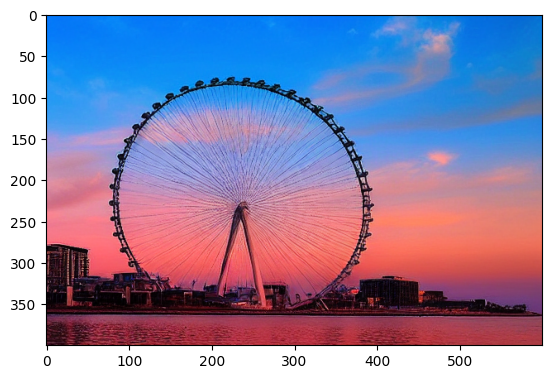

In [11]:
import matplotlib.pyplot as plt
plt.imshow(out_image)

In [14]:
editor.show()

Canvas(height=400, width=600)